# Test results EDA

Loads a `test_results_*.csv` from `misc/results/`, parses frame ids from `file_name` (PointNet `*_pcd_<n>.ply` or CoRe++ `*_<n>.png`), and normalizes cohort to a numeric `year` column from either `year` or `growing_season`. Builds:

- **`df_frames`** — one row per partial scan (every potato × frame in the file).
- **`df_per_potato`** — per tuber: how many frames, min/max/**median** frame number, **median `exec_time_ms`** across frames.
- **`df_middle`** — one row per potato: the scan whose `frame_id` is **closest** to the median frame index for that potato (tie-break: smaller `frame_id`). Includes that row’s metrics plus **`median_exec_time_ms`** from `df_per_potato` for comparison.

In [41]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd


def parse_frame_id(file_name: str) -> int | None:
    """Parse scan index from PointNet PLY or CoRe++ RGB file_name."""
    stem = Path(str(file_name).replace("\\", "/")).stem
    m = re.search(r"pcd_(\d+)$", stem)
    if m:
        return int(m.group(1))
    m = re.search(r"_(\d+)$", stem)
    if m:
        return int(m.group(1))
    return None

BASE = Path.cwd()
RESULT_PATH = BASE / "results/5472418_32_t18_05_205039.csv"
DATA_ROOT = BASE.parent / "data" / "3DPotatoTwin"
BIN_WIDTH_ML = 50
MATCH_SEED = 50
# Bin must have at least this many 2023 train tubers to count as "in distribution".
MIN_TRAIN_PER_BIN = 2
# Target number of 2025 tubers, allocated across bins by 2023 train proportions.
TARGET_MATCH_N = 90
# Per-bin ceiling vs train count when sampling toward that mix.
MAX_OVERSAMPLE_RATIO = 5


def _volume_bin_edges(volumes: pd.Series, bin_width: float) -> np.ndarray:
    lo = float(np.nanmin(volumes))
    hi = float(np.nanmax(volumes))
    start = np.floor(lo / bin_width) * bin_width
    end = np.ceil(hi / bin_width) * bin_width
    return np.arange(start, end + bin_width, bin_width)


def _assign_bins(volumes: pd.Series, edges: np.ndarray) -> pd.Categorical:
    return pd.cut(volumes, bins=edges, right=False, include_lowest=True)


def _allocate_bin_counts(ref_counts: pd.Series, n_total: int) -> pd.Series:
    props = ref_counts / ref_counts.sum()
    raw = props * n_total
    targets = np.floor(raw).astype(int)
    remainder = n_total - int(targets.sum())
    if remainder:
        for b in (raw - targets).sort_values(ascending=False).index[:remainder]:
            targets[b] += 1
    return targets


def _select_2025_matched(
    pool: pd.DataFrame,
    ref_counts: pd.Series,
    *,
    id_col: str,
    vol_col: str,
    edges: np.ndarray,
    min_train_per_bin: int,
    target_n: int,
    max_oversample_ratio: float,
    seed: int,
) -> tuple[list[str], pd.Series]:
    """2025 tubers in train-supported bins, sampled toward 2023 train volume mix."""
    rng = np.random.default_rng(seed)
    pool = pool.copy()
    pool["_bin"] = _assign_bins(pool[vol_col], edges)

    ref_supported = ref_counts[ref_counts >= min_train_per_bin]
    pool = pool[pool["_bin"].isin(ref_supported.index)]

    targets = _allocate_bin_counts(ref_supported, target_n)
    for b in targets.index:
        train_n = int(ref_supported[b])
        cap = max(train_n, int(np.ceil(train_n * max_oversample_ratio)))
        targets[b] = min(int(targets[b]), cap)

    selected: list[str] = []
    for b, n_take in targets.items():
        if n_take <= 0:
            continue
        ids = pool.loc[pool["_bin"] == b, id_col].unique()
        n_take = min(n_take, len(ids))
        if n_take == len(ids):
            selected.extend(ids.tolist())
        else:
            selected.extend(rng.choice(ids, size=n_take, replace=False).tolist())

    return selected, targets


def ensure_year_column(df: pd.DataFrame) -> pd.DataFrame:
    """Unify cohort as numeric ``year`` from ``year`` and/or ``growing_season`` columns."""
    out = df.copy()
    year = pd.Series(np.nan, index=out.index, dtype=float)
    if "year" in out.columns:
        year = pd.to_numeric(out["year"], errors="coerce")
    if "growing_season" in out.columns:
        year = year.fillna(pd.to_numeric(out["growing_season"], errors="coerce"))
    if year.isna().all():
        raise KeyError("Results CSV must contain 'year' or 'growing_season' with values")
    out["year"] = year
    return out


def normalize_results_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure ``unique_id`` exists (strip whitespace; accept ``label`` alias)."""
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    if "unique_id" not in out.columns:
        if "label" in out.columns:
            out = out.rename(columns={"label": "unique_id"})
        else:
            raise KeyError(
                "Results CSV must contain 'unique_id' or 'label'; "
                f"got columns: {list(out.columns)}"
            )
    return out


def load_results_csv(path: Path) -> pd.DataFrame:
    """Load a test_results CSV: parse frame_id, unify year, validate columns."""
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path.resolve()}")
    df = normalize_results_columns(pd.read_csv(path))
    df["frame_id"] = df["file_name"].astype(str).map(parse_frame_id)
    if df["frame_id"].isna().any():
        bad = df.loc[df["frame_id"].isna(), "file_name"].head(5).tolist()
        raise ValueError(f"Could not parse frame id from file_name (examples): {bad}")
    df["frame_id"] = df["frame_id"].astype(int)
    return ensure_year_column(df)


def subset_analysis_frames(
    df_all: pd.DataFrame, selected_2025_ids: list[str]
) -> pd.DataFrame:
    """All 2023 test frames + volume-matched 2025 subset (same tubers as cell 1)."""
    df_all = normalize_results_columns(df_all)
    mask_2023 = df_all["year"].eq(2023)
    mask_2025 = df_all["year"].eq(2025) & df_all["unique_id"].isin(selected_2025_ids)
    out = pd.concat(
        [df_all.loc[mask_2023], df_all.loc[mask_2025]],
        ignore_index=True,
    )
    out = out.sort_values(["unique_id", "frame_id"], kind="mergesort").reset_index(drop=True)
    if "unique_id" not in out.columns:
        raise KeyError(f"subset_analysis_frames lost unique_id; columns={list(out.columns)}")
    return out


def middle_frame_per_potato(df: pd.DataFrame) -> pd.DataFrame:
    """One row per tuber: frame closest to the median frame index."""
    df = normalize_results_columns(df)
    rows: list[pd.Series] = []
    for uid, grp in df.groupby("unique_id", sort=False):
        med = grp["frame_id"].median()
        idx = (grp["frame_id"] - med).abs().idxmin()
        row = grp.loc[idx].copy()
        row["unique_id"] = uid
        rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True)


def mean_volume_per_potato(df: pd.DataFrame) -> pd.DataFrame:
    """One row per tuber: mean predicted volume across frames."""
    df = normalize_results_columns(df)
    return df.groupby("unique_id", as_index=False).agg(
        pred_volume_ml=("pred_volume_ml", "mean"),
        gt_volume_ml=("gt_volume_ml", "first"),
        cultivar=("cultivar", "first"),
        year=("year", "first"),
    )


df_frames_all = load_results_csv(RESULT_PATH)

# --- 2025 test subset: match 2023 train volume distribution (20 mL bins) ---
traits = pd.read_csv(DATA_ROOT / "mesh_traits.csv")
splits = pd.read_csv(DATA_ROOT / "splits.csv")
meta = splits.merge(traits, on="label", how="left")
meta["gt_volume_ml"] = pd.to_numeric(meta["volume (cm3)"], errors="coerce")

train_2023 = meta[(meta["split"] == "train") & (meta["year"] == 2023)].dropna(subset=["gt_volume_ml"])
pot_2025 = (
    df_frames_all.loc[df_frames_all["year"] == 2025]
    .groupby("unique_id", as_index=False)
    .agg(gt_volume_ml=("gt_volume_ml", "first"))
)

vols_ref = pd.concat([train_2023["gt_volume_ml"], pot_2025["gt_volume_ml"]], ignore_index=True)
bin_edges = _volume_bin_edges(vols_ref, BIN_WIDTH_ML)
train_bins = _assign_bins(train_2023["gt_volume_ml"], bin_edges)
ref_counts = train_bins.value_counts().sort_index()

selected_2025_ids, bin_targets = _select_2025_matched(
    pot_2025,
    ref_counts,
    id_col="unique_id",
    vol_col="gt_volume_ml",
    edges=bin_edges,
    min_train_per_bin=MIN_TRAIN_PER_BIN,
    target_n=TARGET_MATCH_N,
    max_oversample_ratio=MAX_OVERSAMPLE_RATIO,
    seed=MATCH_SEED,
)

mask_2023 = df_frames_all["year"].eq(2023)
mask_2025 = df_frames_all["year"].eq(2025)

df_2023 = df_frames_all.loc[mask_2023].copy()
test_2025_matched = df_frames_all.loc[
    mask_2025 & df_frames_all["unique_id"].isin(selected_2025_ids)
].copy()

df_frames = subset_analysis_frames(df_frames_all, selected_2025_ids)

# Quick check: relative bin distribution before vs after (one row per potato)
def _rel_bin_hist(vols: pd.Series) -> pd.Series:
    counts = _assign_bins(vols, bin_edges).value_counts().sort_index()
    return (counts / counts.sum()).rename(lambda iv: f"{iv.left:.0f}-{iv.right:.0f}")


pot_2025_sel = pot_2025[pot_2025["unique_id"].isin(selected_2025_ids)]
print(
    f"df_frames = df_2023 + test_2025_matched\n"
    f"  2023: {df_2023['unique_id'].nunique()} tubers, {len(df_2023)} frames\n"
    f"  2025 matched: {test_2025_matched['unique_id'].nunique()} tubers, {len(test_2025_matched)} frames "
    f"(from {pot_2025['unique_id'].nunique()} / {int(mask_2025.sum())} total 2025)\n"
    f"  combined: {df_frames['unique_id'].nunique()} tubers, {len(df_frames)} frames"
)
print(
    f"Selection: train-supported bins (min_train/bin={MIN_TRAIN_PER_BIN}), "
    f"target_n={TARGET_MATCH_N}, oversample_cap={MAX_OVERSAMPLE_RATIO}x, "
    f"bins={BIN_WIDTH_ML} mL, seed={MATCH_SEED}"
)
cmp = pd.DataFrame(
    {
        "train_2023": _rel_bin_hist(train_2023["gt_volume_ml"]),
        "test_2025_all": _rel_bin_hist(pot_2025["gt_volume_ml"]),
        "test_2025_matched": _rel_bin_hist(pot_2025_sel["gt_volume_ml"]),
    }
).fillna(0)
print(cmp.round(3).to_string())

median_exec_time_all = df_frames["exec_time_ms"].median()
print(f"\nMedian exec_time_ms over all rows: {median_exec_time_all:.2f} ms")

df_frames = df_2023 + test_2025_matched
  2023: 51 tubers, 1425 frames
  2025 matched: 84 tubers, 2970 frames (from 230 / 8201 total 2025)
  combined: 135 tubers, 4395 frames
Selection: train-supported bins (min_train/bin=2), target_n=90, oversample_cap=5x, bins=50 mL, seed=50
              train_2023  test_2025_all  test_2025_matched
gt_volume_ml                                              
0-50               0.013          0.270              0.012
50-100             0.300          0.126              0.321
100-150            0.241          0.091              0.250
150-200            0.236          0.074              0.202
200-250            0.118          0.126              0.131
250-300            0.059          0.113              0.060
300-350            0.025          0.078              0.024
350-400            0.000          0.052              0.000
400-450            0.004          0.035              0.000
450-500            0.004          0.017              0.000
500-550       

Mean per tuber: 5472418_32_t18_05_205039.csv  (135 tubers)
Mean per tuber: test_results_5471226_bbox_125cm.csv  (135 tubers, 4395 frames)
Frames: 5472418_32_t18_05_205039.csv mean_encoder_ms=4.55  mean_decoder_ms=15.01  mean_convex_hull_ms=4.56
Frames: test_results_5471226_bbox_125cm.csv mean_encoder_ms=4.95  mean_decoder_ms=14.94  mean_convex_hull_ms=6.47


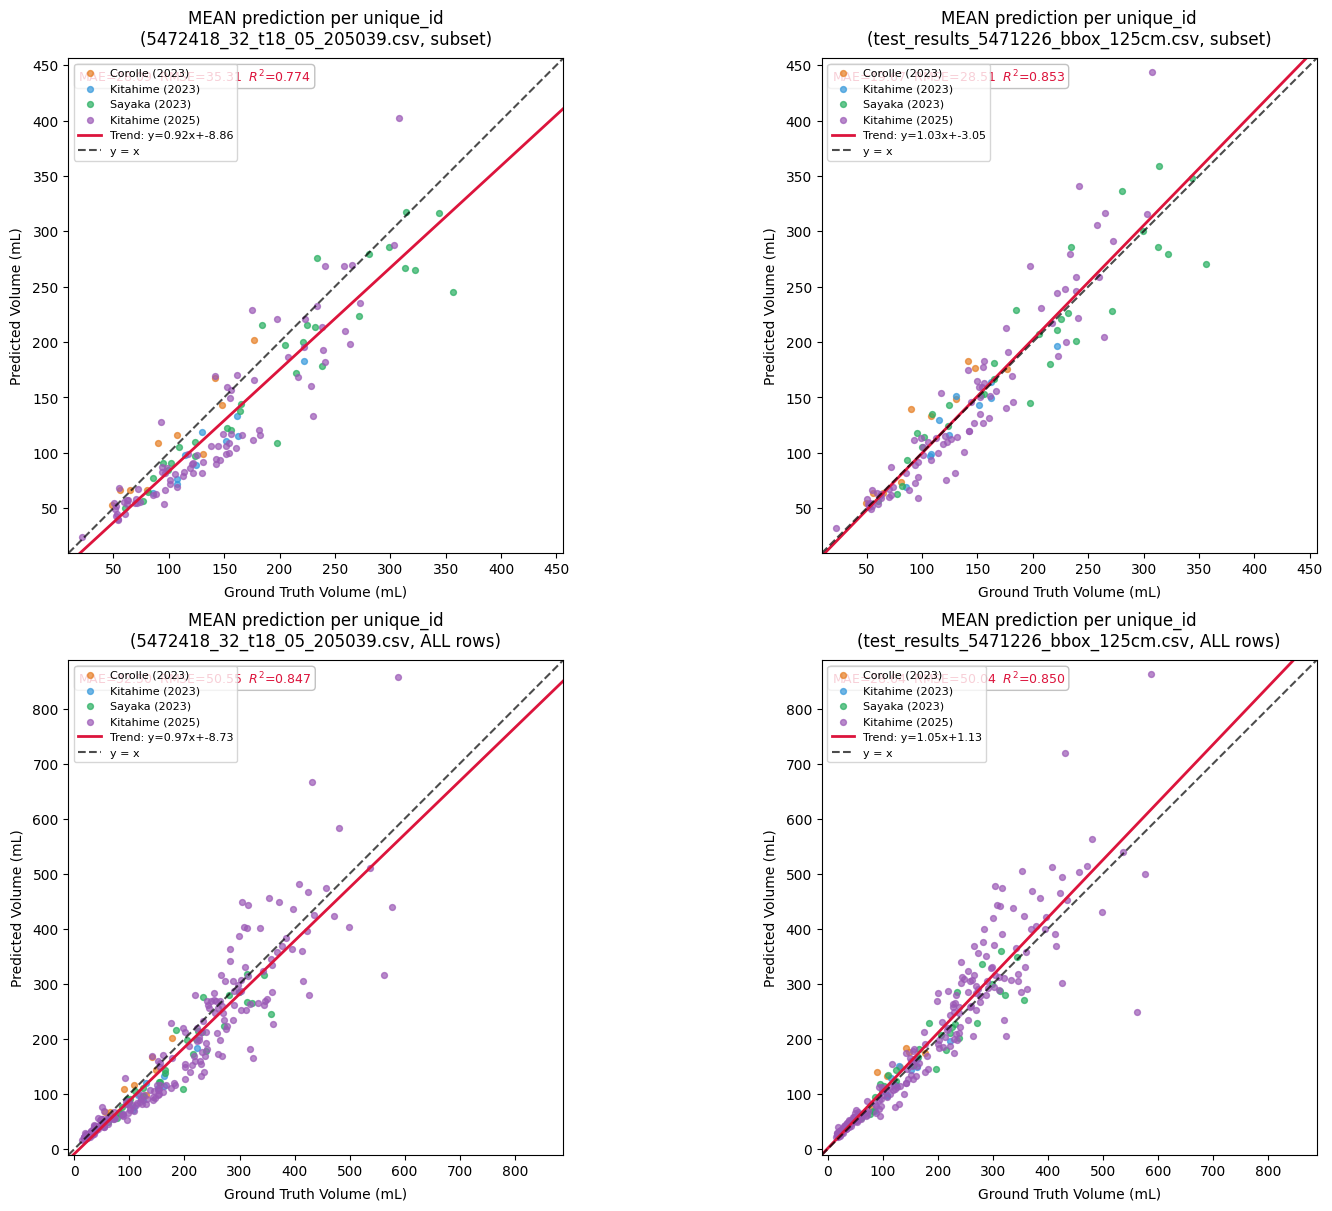

In [42]:
from __future__ import annotations

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RESULT_PATH_MEAN = BASE / "results/test_results_5471226_bbox_125cm.csv"

_required = ("selected_2025_ids", "mean_volume_per_potato", "subset_analysis_frames", "load_results_csv")
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError(f"Run the load cell first; missing: {_missing}")

# Rebuild primary analysis set if this cell is run without df_frames
if "df_frames" not in globals():
    df_frames = subset_analysis_frames(load_results_csv(RESULT_PATH), selected_2025_ids)
elif "frame_id" not in df_frames.columns:
    df_frames = subset_analysis_frames(load_results_csv(RESULT_PATH), selected_2025_ids)

# --- Aggregation 1: mean prediction per unique_id (primary RESULT_PATH / df_frames) ---
df_mean1 = mean_volume_per_potato(df_frames)

# --- Aggregation 2: mean pred_volume_ml per unique_id (comparison CSV, same subset) ---
df_frames_mean = subset_analysis_frames(
    load_results_csv(RESULT_PATH_MEAN),
    selected_2025_ids,
)
df_mean2 = mean_volume_per_potato(df_frames_mean)

# Keep only tubers present in both result files
_common_ids = set(df_mean1["unique_id"]) & set(df_mean2["unique_id"])
df_mean1 = df_mean1[df_mean1["unique_id"].isin(_common_ids)].reset_index(drop=True)
df_mean2 = df_mean2[df_mean2["unique_id"].isin(_common_ids)].reset_index(drop=True)

print(
    f"Mean per tuber: {RESULT_PATH.name}  ({len(df_mean1)} tubers)\n"
    f"Mean per tuber: {RESULT_PATH_MEAN.name}  ({len(df_mean2)} tubers, "
    f"{len(df_frames_mean)} frames)"
)

# --- Also show mean encoder_ms, decoder_ms and convex_hull_ms per CSV ---
def safe_mean(df, col):
    return df[col].mean() if col in df.columns else float('nan')

def print_timing_stats(label, df):
    mean_encoder = safe_mean(df, "encoder_ms")
    mean_decoder = safe_mean(df, "decoder_ms")
    mean_convex = safe_mean(df, "convex_hull_ms")
    print(
        f"{label:<26} "
        f"mean_encoder_ms={mean_encoder:.2f}  "
        f"mean_decoder_ms={mean_decoder:.2f}  "
        f"mean_convex_hull_ms={mean_convex:.2f}"
    )

print_timing_stats(f"Frames: {RESULT_PATH.name}", df_frames)
print_timing_stats(f"Frames: {RESULT_PATH_MEAN.name}", df_frames_mean)

# --- Shared helpers (group = cultivar + cohort year, not cultivar alone) ---
def attach_cohort_group(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "year" not in out.columns:
        raise KeyError("mean_volume_per_potato must include 'year'; re-run the load cell")
    y = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    cv = out["cultivar"].astype(str).str.strip()
    out["group"] = cv + " (" + y.astype(str) + ")"
    return out

df_mean1 = attach_cohort_group(df_mean1)
df_mean2 = attach_cohort_group(df_mean2)

_GROUP_ORDER = [
    "Corolle (2023)",
    "Kitahime (2023)",
    "Sayaka (2023)",
    "Kitahime (2025)",
]
_present = set(pd.concat([df_mean1["group"], df_mean2["group"]]))
groups = [g for g in _GROUP_ORDER if g in _present]
groups += sorted(g for g in _present if g not in _GROUP_ORDER)

custom_colors = ["#e67e22", "#3498db", "#27ae60", "#9b59b6"]
colors = [custom_colors[i % len(custom_colors)] for i in range(len(groups))]

def _add_regression(ax, df, vmin, vmax):
    X = df["gt_volume_ml"].values.reshape(-1, 1)
    y = df["pred_volume_ml"].values
    reg = LinearRegression().fit(X, y)
    x_fit = np.array([vmin, vmax]).reshape(-1, 1)
    ax.plot(x_fit.flatten(), reg.predict(x_fit), color="crimson", lw=2,
            label=f"Trend: y={reg.coef_[0]:.2f}x+{reg.intercept_:.2f}")
    ax.plot([vmin, vmax], [vmin, vmax], color="k", linestyle="--", alpha=0.7, label="y = x")
    mae  = mean_absolute_error(df["gt_volume_ml"], df["pred_volume_ml"])
    rmse = np.sqrt(mean_squared_error(df["gt_volume_ml"], df["pred_volume_ml"]))
    r2   = r2_score(df["gt_volume_ml"], df["pred_volume_ml"])
    return f"MAE={mae:.2f}  RMSE={rmse:.2f}  $R^2$={r2:.3f}"

def _scatter_panel(ax, df, colors, groups, title, vminmax):
    vmin, vmax = vminmax
    for i, group in enumerate(groups):
        mask = df["group"] == group
        if not mask.any():
            continue
        ax.scatter(
            df.loc[mask, "gt_volume_ml"],
            df.loc[mask, "pred_volume_ml"],
            s=18, alpha=0.7,
            color=colors[i % len(colors)],
            label=str(group),
        )
    metrics_text = _add_regression(ax, df, vmin, vmax)
    ax.text(
        0.02, 0.98, metrics_text,
        transform=ax.transAxes, fontsize=9, color="crimson",
        verticalalignment="top", horizontalalignment="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.95, edgecolor="0.75"),
    )
    ax.set_xlabel("Ground Truth Volume (mL)", labelpad=6)
    ax.set_ylabel("Predicted Volume (mL)", labelpad=6)
    ax.set_title(title, pad=10)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.8)
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect('equal', adjustable='box')

# === Also plot "full" sets: mean per unique_id for all available rows from both CSVs, with no subset selection ===

# Full means for all potatoes from RESULT_PATH
df_frames_all_full = load_results_csv(RESULT_PATH)
df_full1 = mean_volume_per_potato(df_frames_all_full)
df_full1 = attach_cohort_group(df_full1)

# Full means for all potatoes from RESULT_PATH_MEAN
df_frames_mean_full = load_results_csv(RESULT_PATH_MEAN)
df_full2 = mean_volume_per_potato(df_frames_mean_full)
df_full2 = attach_cohort_group(df_full2)

# Ensure group listing for possible novel cohorts
_present_full = set(pd.concat([df_full1["group"], df_full2["group"]]))
groups_full = [g for g in _GROUP_ORDER if g in _present_full]
groups_full += sorted(g for g in _present_full if g not in _GROUP_ORDER)
colors_full = [custom_colors[i % len(custom_colors)] for i in range(len(groups_full))]

# --- Axis sync: Compute min/max for the top (subset) and bottom (full) rows *separately*,
#     so that axes are synced only for plots next to each other, not all 4
#   - Top row uses all (subset) points for limits
_top_gt = pd.concat([df_mean1["gt_volume_ml"], df_mean2["gt_volume_ml"]], ignore_index=True)
_top_pred = pd.concat([df_mean1["pred_volume_ml"], df_mean2["pred_volume_ml"]], ignore_index=True)
top_axes_min = float(min(_top_gt.min(), _top_pred.min()))
top_axes_max = float(max(_top_gt.max(), _top_pred.max()))
top_margin = 0.03 * (top_axes_max - top_axes_min)
top_axes_min -= top_margin
top_axes_max += top_margin
top_limits = (top_axes_min, top_axes_max)

#   - Bottom row uses all (full) points for limits
_bot_gt = pd.concat([df_full1["gt_volume_ml"], df_full2["gt_volume_ml"]], ignore_index=True)
_bot_pred = pd.concat([df_full1["pred_volume_ml"], df_full2["pred_volume_ml"]], ignore_index=True)
bot_axes_min = float(min(_bot_gt.min(), _bot_pred.min()))
bot_axes_max = float(max(_bot_gt.max(), _bot_pred.max()))
bot_margin = 0.03 * (bot_axes_max - bot_axes_min)
bot_axes_min -= bot_margin
bot_axes_max += bot_margin
bot_limits = (bot_axes_min, bot_axes_max)

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12), constrained_layout=True)

# Top row: matching subset (use per-row shared axes)
_scatter_panel(
    axes[0, 0], df_mean1, colors, groups,
    f"MEAN prediction per unique_id\n({RESULT_PATH.name}, subset)", top_limits,
)
_scatter_panel(
    axes[0, 1], df_mean2, colors, groups,
    f"MEAN prediction per unique_id\n({RESULT_PATH_MEAN.name}, subset)", top_limits,
)

# Bottom row: full sets (UNfiltered, per each CSV) (use per-row shared axes)
_scatter_panel(
    axes[1, 0], df_full1, colors_full, groups_full,
    f"MEAN prediction per unique_id\n({RESULT_PATH.name}, ALL rows)", bot_limits,
)
_scatter_panel(
    axes[1, 1], df_full2, colors_full, groups_full,
    f"MEAN prediction per unique_id\n({RESULT_PATH_MEAN.name}, ALL rows)", bot_limits,
)

plt.show()


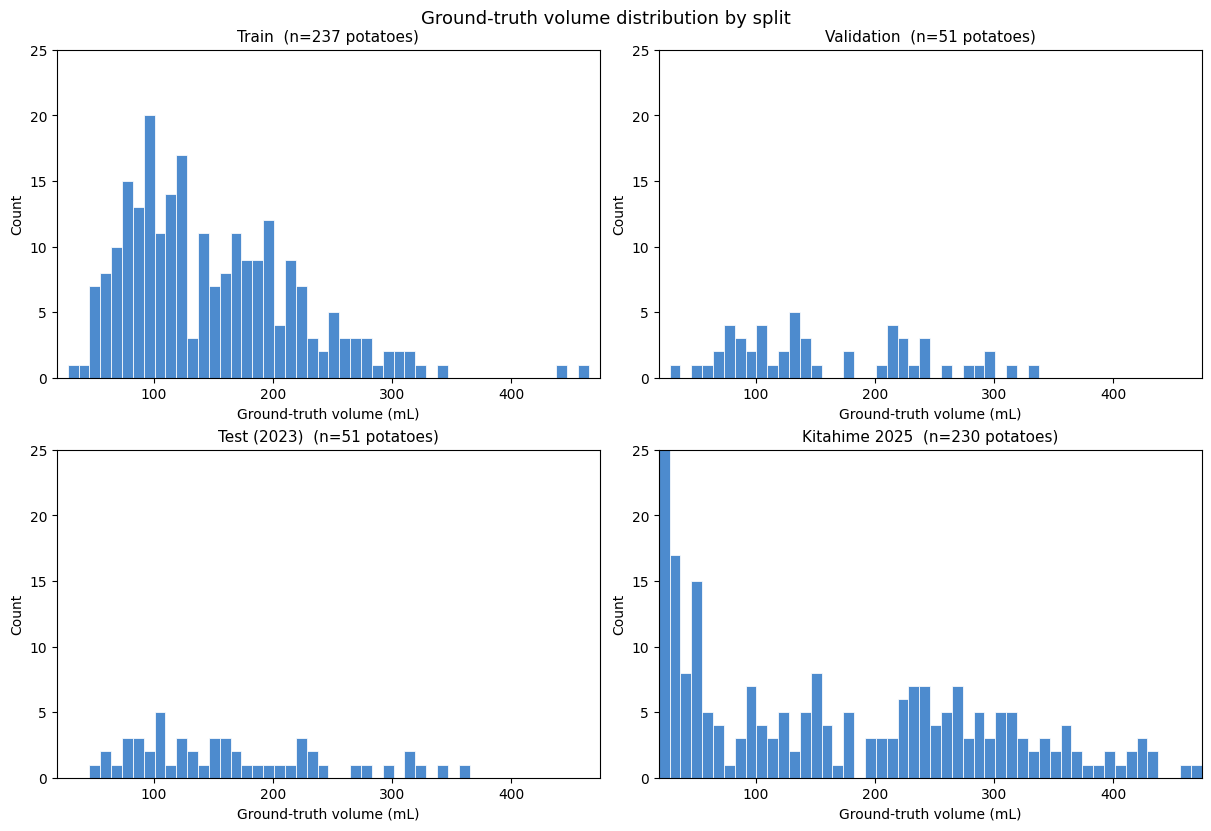

In [39]:
# Ground-truth volume distribution per split (one row per potato)
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = BASE.parent / "data" / "3DPotatoTwin"
GT_PATH = DATA_ROOT / "mesh_traits.csv"
SPLITS_PATH = DATA_ROOT / "splits.csv"

if not GT_PATH.is_file() or not SPLITS_PATH.is_file():
    raise FileNotFoundError(f"Missing dataset CSVs under {DATA_ROOT.resolve()}")

gt = pd.read_csv(GT_PATH)
splits = pd.read_csv(SPLITS_PATH)
df_gt = splits.merge(gt, on="label", how="left")
split_col = "split_x" if "split_x" in df_gt.columns else "split"

df_gt["gt_volume_ml"] = pd.to_numeric(df_gt["volume (cm3)"], errors="coerce")
df_gt["gt_volume_ml"] = df_gt["gt_volume_ml"]


is_2025 = df_gt["label"].astype(str).str.match(r"^2025-", na=False)

PANELS = [
    ("Train", df_gt[df_gt[split_col] == "train"]),
    ("Validation", df_gt[df_gt[split_col] == "val"]),
    ("Test (2023)", df_gt[(df_gt[split_col] == "test") & ~is_2025]),
    ("Kitahime 2025", df_gt[is_2025]),
]

N_BINS = 50
all_volumes = df_gt["gt_volume_ml"].to_numpy()
x_lo = float(np.nanpercentile(all_volumes, 1))
x_hi = float(np.nanpercentile(all_volumes, 99))
bins = np.linspace(x_lo, x_hi, N_BINS + 1)

ymax = 0
for _, sub in PANELS:
    if len(sub):
        ymax = max(ymax, int(np.histogram(sub["gt_volume_ml"], bins=bins)[0].max()))
ymax = max(ymax, 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (title, sub) in zip(axes, PANELS):
    n = len(sub)
    ax.hist(
        sub["gt_volume_ml"],
        bins=bins,
        color="#3A7EC9",
        edgecolor="white",
        linewidth=0.6,
        alpha=0.9,
    )
    ax.set_title(f"{title}  (n={n} potatoes)", fontsize=11)
    ax.set_xlabel("Ground-truth volume (mL)")
    ax.set_ylabel("Count")
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0, ymax)

fig.suptitle("Ground-truth volume distribution by split", fontsize=13, y=1.02)
plt.show()


  train_near_n    = INTEGER count of train scans with volume within +/-25 mL (0 .. 237, NOT binary)
  train_density   = smooth sum of Gaussian weights (sigma=20 mL)

train_near_n distribution on test: min=1, max=85, median=49, mean=48.3

gt_volume_ml     vs abs_err       Pearson=+0.539  Spearman=+0.590  (n=135)
train_near_n     vs abs_err       Pearson=-0.305  Spearman=-0.203  (n=135)
train_density    vs abs_err       Pearson=-0.300  Spearman=-0.173  (n=135)

--- After regressing out gt_volume_ml (volume-adjusted / partial) ---
train_near_n_resid vs abs_err_resid  Pearson=+0.108  Spearman=+0.153  (n=135)
train_density_resid vs abs_err_resid  Pearson=+0.135  Spearman=+0.159  (n=135)

OLS: abs_err ~ gt_volume_ml + train_near_n  (n=135)
  coef(volume)       = +0.1514 mL per mL GT
  coef(train_near_n) = +0.1066 mL per +1 train scan
  intercept          = -3.49 mL



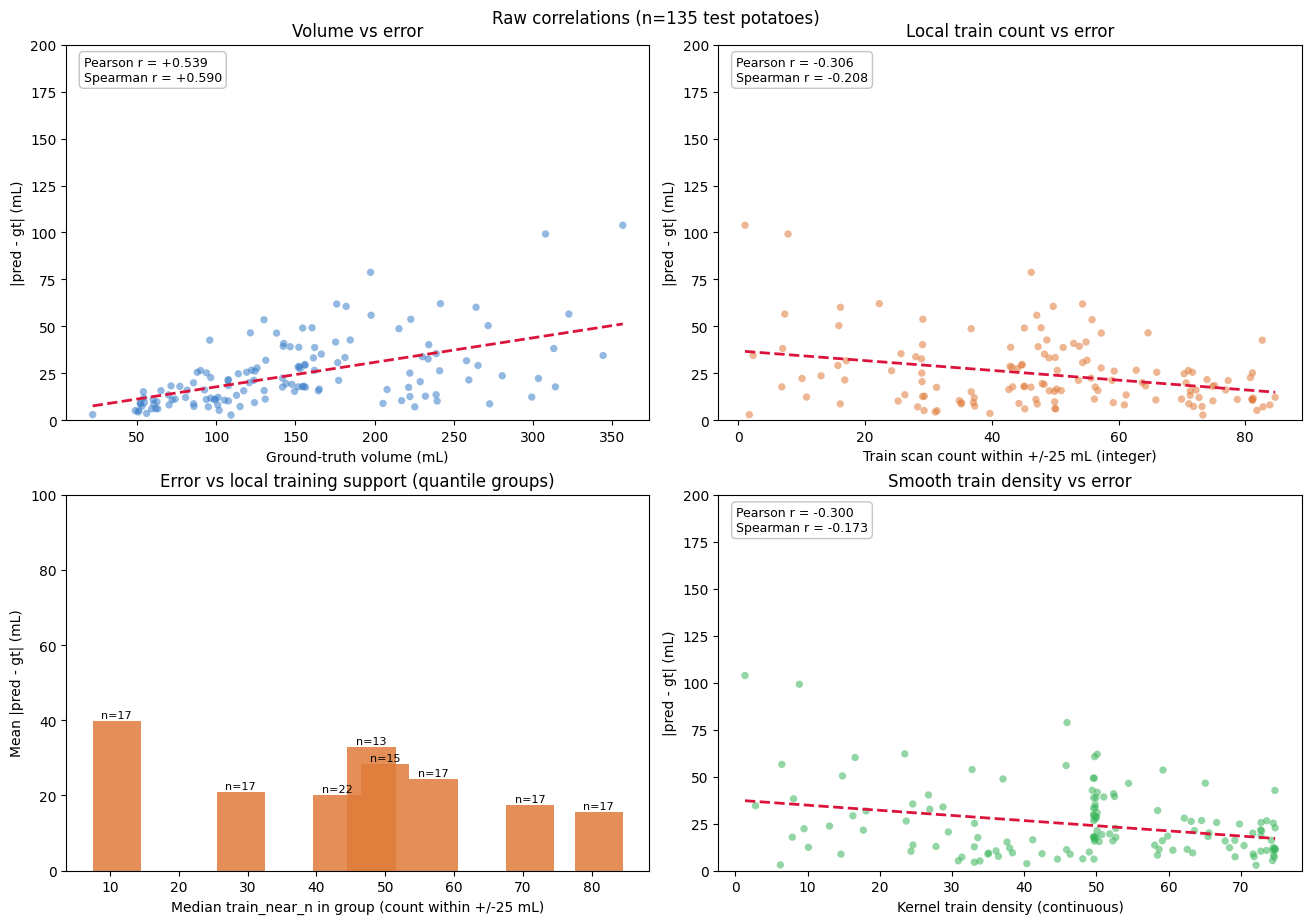

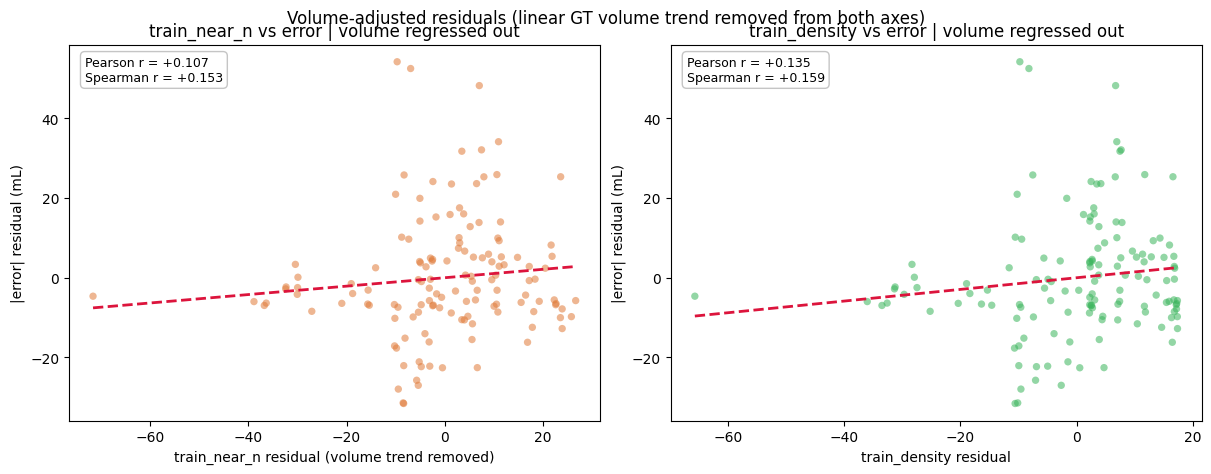

In [33]:
# Correlation: train coverage vs test error (per potato, no binning)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

MAX_GT_ML = 1000  # match prediction-error cell
BANDWIDTH_ML = 25.0  # count train laser scans within +/- this many mL
KERNEL_SIGMA_ML = 20.0  # Gaussian kernel width for smooth train density

DATA_ROOT = BASE.parent / "data" / "3DPotatoTwin"
traits = pd.read_csv(DATA_ROOT / "mesh_traits.csv")
splits = pd.read_csv(DATA_ROOT / "splits.csv")
meta = splits.merge(traits, on="label", how="left")
meta["gt_volume_ml"] = pd.to_numeric(meta["volume (cm3)"], errors="coerce")
train_vols = (
    meta.loc[meta["split"] == "train", "gt_volume_ml"]
    .dropna()
    .to_numpy(dtype=float)
)
# df_frames = pd.read_csv(RESULT_PATH)

df_frames["abs_err"] = (df_frames["pred_volume_ml"] - df_frames["gt_volume_ml"]).abs()
test_pot = (
    df_frames.groupby("unique_id", as_index=False)
    .agg(
        gt_volume_ml=("gt_volume_ml", "first"),
        abs_err=("abs_err", "mean"),
        year=("year", "first"),
    )
)

test_vols = test_pot["gt_volume_ml"].to_numpy(dtype=float)
dist = np.abs(test_vols[:, None] - train_vols[None, :])  # (n_test, n_train)

# Per train-test pair: inside band is 0/1; summing over all train scans gives an INTEGER COUNT (not binary).
test_pot["train_near_n"] = (dist <= BANDWIDTH_ML).sum(axis=1).astype(int)
test_pot["train_density"] = np.exp(-0.5 * (dist / KERNEL_SIGMA_ML) ** 2).sum(axis=1)


def _pearson(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _spearman(x, y):
    return _pearson(pd.Series(x).rank(), pd.Series(y).rank())


def _report(name_x, x, name_y, y):
    print(
        f"{name_x:16s} vs {name_y:12s}  "
        f"Pearson={_pearson(x, y):+.3f}  Spearman={_spearman(x, y):+.3f}  (n={len(x)})"
    )


print(
    f"  train_near_n    = INTEGER count of train scans with volume within +/-{BANDWIDTH_ML:.0f} mL "
    f"(0 .. {len(train_vols)}, NOT binary)\n"
    f"  train_density   = smooth sum of Gaussian weights (sigma={KERNEL_SIGMA_ML:.0f} mL)\n"
)
print(
    "train_near_n distribution on test:",
    f"min={test_pot['train_near_n'].min()}, max={test_pot['train_near_n'].max()}, "
    f"median={test_pot['train_near_n'].median():.0f}, mean={test_pot['train_near_n'].mean():.1f}\n",
)
_report("gt_volume_ml", test_pot["gt_volume_ml"], "abs_err", test_pot["abs_err"])
_report("train_near_n", test_pot["train_near_n"], "abs_err", test_pot["abs_err"])
_report("train_density", test_pot["train_density"], "abs_err", test_pot["abs_err"])


def _residualize(y, x):
    """OLS residuals after regressing y on x (with intercept)."""
    y = np.asarray(y, float)
    x = np.asarray(x, float).reshape(-1, 1)
    return y - LinearRegression().fit(x, y).predict(x)


test_pot["abs_err_resid"] = _residualize(test_pot["abs_err"], test_pot["gt_volume_ml"])
test_pot["train_near_n_resid"] = _residualize(test_pot["train_near_n"], test_pot["gt_volume_ml"])
test_pot["train_density_resid"] = _residualize(test_pot["train_density"], test_pot["gt_volume_ml"])

print("\n--- After regressing out gt_volume_ml (volume-adjusted / partial) ---")
_report("train_near_n_resid", test_pot["train_near_n_resid"], "abs_err_resid", test_pot["abs_err_resid"])
_report("train_density_resid", test_pot["train_density_resid"], "abs_err_resid", test_pot["abs_err_resid"])

reg_joint = LinearRegression().fit(
    test_pot[["gt_volume_ml", "train_near_n"]].to_numpy(),
    test_pot["abs_err"].to_numpy(),
)
print(
    f"\nOLS: abs_err ~ gt_volume_ml + train_near_n  (n={len(test_pot)})\n"
    f"  coef(volume)       = {reg_joint.coef_[0]:+.4f} mL per mL GT\n"
    f"  coef(train_near_n) = {reg_joint.coef_[1]:+.4f} mL per +1 train scan\n"
    f"  intercept          = {reg_joint.intercept_:.2f} mL\n"
)


def _scatter_panel(
    ax, x, y, xlabel, ylabel, title, color="#6C5CE7", jitter_x=0.0, ylim=None,
):
    x, y = np.asarray(x, float), np.asarray(y, float)
    if jitter_x > 0:
        rng = np.random.default_rng(0)
        x = x + rng.uniform(-jitter_x, jitter_x, size=len(x))
    ax.scatter(x, y, s=28, alpha=0.55, color=color, edgecolors="none")
    if len(x) >= 2 and np.std(x) > 0:
        coef = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(coef, xs), color="crimson", lw=2, ls="--")
    r_p, r_s = _pearson(x, y), _spearman(x, y)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.text(
        0.03,
        0.97,
        f"Pearson r = {r_p:+.3f}\nSpearman r = {r_s:+.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9, edgecolor="0.75"),
    )
    if ylim is not None:
        ax.set_ylim(ylim)


fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

_scatter_panel(
    axes[0, 0],
    test_pot["gt_volume_ml"],
    test_pot["abs_err"],
    "Ground-truth volume (mL)",
    "|pred - gt| (mL)",
    "Volume vs error",
    color="#3A7EC9",
    ylim=(0, 200),
)
_scatter_panel(
    axes[0, 1],
    test_pot["train_near_n"],
    test_pot["abs_err"],
    f"Train scan count within +/-{BANDWIDTH_ML:.0f} mL (integer)",
    "|pred - gt| (mL)",
    "Local train count vs error",
    color="#E07B39",
    jitter_x=0.35,
    ylim=(0, 200),
)

# Mean error vs how much train data exists nearby (quantile groups on the count)
n_support_bins = 8
test_pot["support_bin"] = pd.qcut(
    test_pot["train_near_n"], q=n_support_bins, duplicates="drop"
)
by_support = (
    test_pot.groupby("support_bin", observed=True)
    .agg(
        train_n_med=("train_near_n", "median"),
        mean_err=("abs_err", "mean"),
        n_test=("unique_id", "count"),
    )
    .reset_index()
)
ax = axes[1, 0]
x = by_support["train_n_med"].to_numpy()
y = by_support["mean_err"].to_numpy()
ax.bar(x, y, width=(x.max() - x.min()) / max(len(x) - 1, 1) * 0.7, color="#E07B39", alpha=0.85)
ax.set_xlabel(f"Median train_near_n in group (count within +/-{BANDWIDTH_ML:.0f} mL)")
ax.set_ylabel("Mean |pred - gt| (mL)")
ax.set_title("Error vs local training support (quantile groups)")
for xi, yi, ni in zip(x, y, by_support["n_test"]):
    ax.text(xi, yi + 0.8, f"n={int(ni)}", ha="center", fontsize=8)
# Set y-axis limit to [0, 250] explicitly
ax.set_ylim(0, 100)

_scatter_panel(
    axes[1, 1],
    test_pot["train_density"],
    test_pot["abs_err"],
    "Kernel train density (continuous)",
    "|pred - gt| (mL)",
    "Smooth train density vs error",
    color="#3AB55C",
    ylim=(0, 200),
)

fig.suptitle(
    f"Raw correlations (n={len(test_pot)} test potatoes)",
    fontsize=12,
    y=1.01,
)
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
_scatter_panel(
    axes2[0],
    test_pot["train_near_n_resid"],
    test_pot["abs_err_resid"],
    "train_near_n residual (volume trend removed)",
    "|error| residual (mL)",
    "train_near_n vs error | volume regressed out",
    color="#E07B39",
    jitter_x=0.35,
)
_scatter_panel(
    axes2[1],
    test_pot["train_density_resid"],
    test_pot["abs_err_resid"],
    "train_density residual",
    "|error| residual (mL)",
    "train_density vs error | volume regressed out",
    color="#3AB55C",
)
fig2.suptitle(
    "Volume-adjusted residuals (linear GT volume trend removed from both axes)",
    fontsize=12,
    y=1.02,
)
plt.show()


Fixed 50 mL bins (GT >= 0 mL), one row per bin:

           bin_label  train_n  test_n  mean_abs_err  med_abs_err
vol_bin                                                         
[0, 50)         0-50        3       2          3.68         3.68
[50, 100)     50-100       71      38         14.96        14.31
[100, 150)   100-150       57      34         30.12        31.07
[150, 200)   150-200       56      27         42.31        39.06
[200, 250)   200-250       28      19         37.94        33.13
[250, 300)   250-300       14       8         32.78        29.28
[300, 350)   300-350        6       6         43.21        36.98
[350, 400)   350-400        0       1        111.57       111.57

Across bins (n=8): train_n vs mean_abs_err  Pearson=-0.372  Spearman=-0.405


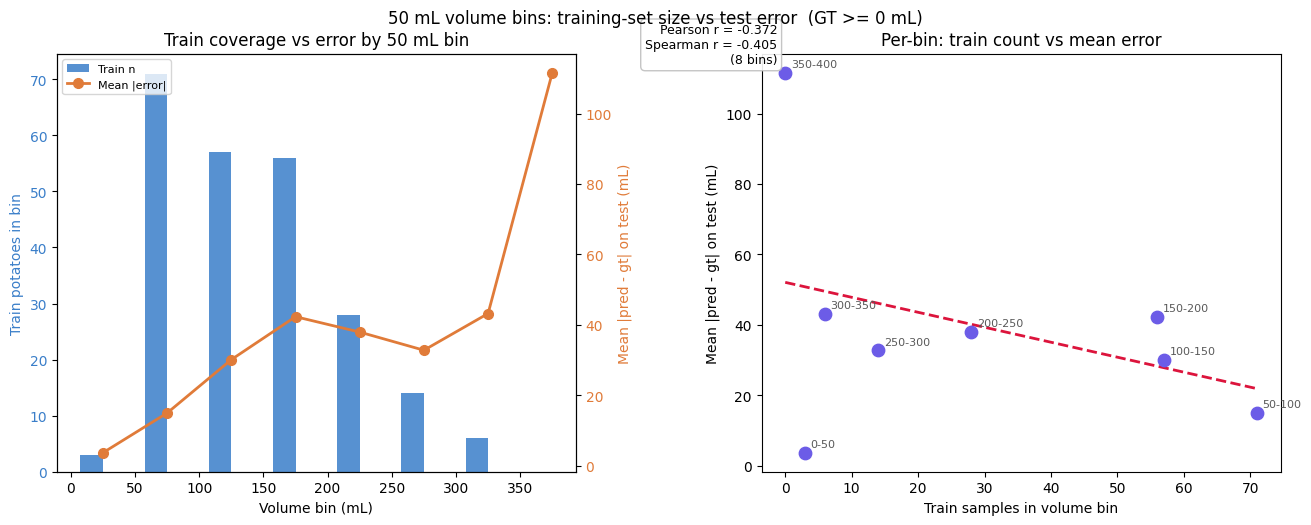

In [43]:
# Fixed 50 mL volume bins: train sample count vs mean test |error| per bin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BIN_WIDTH_ML = 50
MIN_GT_ML = 0  # match prediction-error cell (cell 2)

DATA_ROOT = BASE.parent / "data" / "3DPotatoTwin"
traits = pd.read_csv(DATA_ROOT / "mesh_traits.csv")
splits = pd.read_csv(DATA_ROOT / "splits.csv")
meta = splits.merge(traits, on="label", how="left")
meta["gt_volume_ml"] = pd.to_numeric(meta["volume (cm3)"], errors="coerce")

train_meta = meta[meta["split"] == "train"].dropna(subset=["gt_volume_ml"]).copy()

if "df_frames" not in globals():
    df_frames = ensure_year_column(pd.read_csv(RESULT_PATH))
elif "year" not in df_frames.columns or df_frames["year"].isna().all():
    df_frames = ensure_year_column(df_frames)

test_frames = df_frames.loc[df_frames["gt_volume_ml"] >= MIN_GT_ML].copy()
test_frames["abs_err"] = (test_frames["pred_volume_ml"] - test_frames["gt_volume_ml"]).abs()
test_pot = (
    test_frames.groupby("unique_id", as_index=False)
    .agg(gt_volume_ml=("gt_volume_ml", "first"), abs_err=("abs_err", "mean"))
)

# Fixed-width bins: [50,100), [100,150), ...
bin_edges = np.arange(MIN_GT_ML, 301, BIN_WIDTH_ML)
if bin_edges[-1] < test_pot["gt_volume_ml"].max():
    bin_edges = np.arange(MIN_GT_ML, int(np.ceil(test_pot["gt_volume_ml"].max())) + BIN_WIDTH_ML, BIN_WIDTH_ML)

train_meta["vol_bin"] = pd.cut(
    train_meta["gt_volume_ml"], bins=bin_edges, right=False, include_lowest=True
)
test_pot["vol_bin"] = pd.cut(
    test_pot["gt_volume_ml"], bins=bin_edges, right=False, include_lowest=True
)

bin_summary = pd.concat(
    [
        train_meta.groupby("vol_bin", observed=True).size().rename("train_n"),
        test_pot.groupby("vol_bin", observed=True).agg(
            test_n=("unique_id", "size"),
            mean_abs_err=("abs_err", "mean"),
            med_abs_err=("abs_err", "median"),
        ),
    ],
    axis=1,
)
bin_summary["train_n"] = bin_summary["train_n"].fillna(0).astype(int)
bin_summary = bin_summary.dropna(subset=["mean_abs_err"]).copy()
# .map on a CategoricalIndex stays categorical in pandas 2.x — build float arrays explicitly
_intervals = list(bin_summary.index)
bin_summary["bin_lo"] = np.array([iv.left for iv in _intervals], dtype=float)
bin_summary["bin_hi"] = np.array([iv.right for iv in _intervals], dtype=float)
bin_summary["bin_mid"] = np.array([iv.mid for iv in _intervals], dtype=float)
bin_summary["bin_label"] = [
    f"{int(lo)}-{int(hi)}" for lo, hi in zip(bin_summary["bin_lo"], bin_summary["bin_hi"])
]


def _pearson(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _spearman(x, y):
    return _pearson(pd.Series(x).rank(), pd.Series(y).rank())


print(f"Fixed {BIN_WIDTH_ML} mL bins (GT >= {MIN_GT_ML} mL), one row per bin:\n")
print(
    bin_summary[
        ["bin_label", "train_n", "test_n", "mean_abs_err", "med_abs_err"]
    ].round(2).to_string()
)

if len(bin_summary) >= 3:
    r_p = _pearson(bin_summary["train_n"], bin_summary["mean_abs_err"])
    r_s = _spearman(bin_summary["train_n"], bin_summary["mean_abs_err"])
    print(
        f"\nAcross bins (n={len(bin_summary)}): train_n vs mean_abs_err  "
        f"Pearson={r_p:+.3f}  Spearman={r_s:+.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Left: train count and mean error vs bin (volume on x)
ax = axes[0]
ax2 = ax.twinx()
x = bin_summary["bin_mid"].to_numpy()
w = BIN_WIDTH_ML * 0.35
ax.bar(x - w / 2, bin_summary["train_n"], width=w, color="#3A7EC9", alpha=0.85, label="Train n")
ax2.plot(
    x, bin_summary["mean_abs_err"], color="#E07B39", marker="o", lw=2, ms=7, label="Mean |error|"
)
ax.set_xlabel("Volume bin (mL)")
ax.set_ylabel("Train potatoes in bin", color="#3A7EC9")
ax2.set_ylabel("Mean |pred - gt| on test (mL)", color="#E07B39")
ax.set_title(f"Train coverage vs error by {BIN_WIDTH_ML} mL bin")
ax.tick_params(axis="y", labelcolor="#3A7EC9")
ax2.tick_params(axis="y", labelcolor="#E07B39")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)

# Right: direct train_n vs mean error (one point per bin)
ax = axes[1]
ax.scatter(bin_summary["train_n"], bin_summary["mean_abs_err"], s=80, color="#6C5CE7", zorder=3)
if len(bin_summary) >= 2 and bin_summary["train_n"].nunique() > 1:
    coef = np.polyfit(bin_summary["train_n"], bin_summary["mean_abs_err"], 1)
    xs = np.linspace(bin_summary["train_n"].min(), bin_summary["train_n"].max(), 50)
    ax.plot(xs, np.polyval(coef, xs), color="crimson", lw=2, ls="--")
for _, row in bin_summary.iterrows():
    ax.annotate(
        row["bin_label"],
        (row["train_n"], row["mean_abs_err"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        color="0.35",
    )
ax.set_xlabel("Train samples in volume bin")
ax.set_ylabel("Mean |pred - gt| on test (mL)")
ax.set_title("Per-bin: train count vs mean error")
if len(bin_summary) >= 3:
    ax.text(
        0.03, 0.97,
        f"Pearson r = {r_p:+.3f}\nSpearman r = {r_s:+.3f}\n({len(bin_summary)} bins)",
        transform=ax.transAxes, va="bottom", ha="right", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9, edgecolor="0.75"),
    )

fig.suptitle(
    f"50 mL volume bins: training-set size vs test error  (GT >= {MIN_GT_ML} mL)",
    fontsize=12, y=1.02,
)
plt.show()


Partial axis flip (pre-PCA): (-1, 1, -1)  |  median dist partial->full: 1.57 mm


C:\Users\Jesper\AppData\Local\Temp\ipykernel_24772\3190581153.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


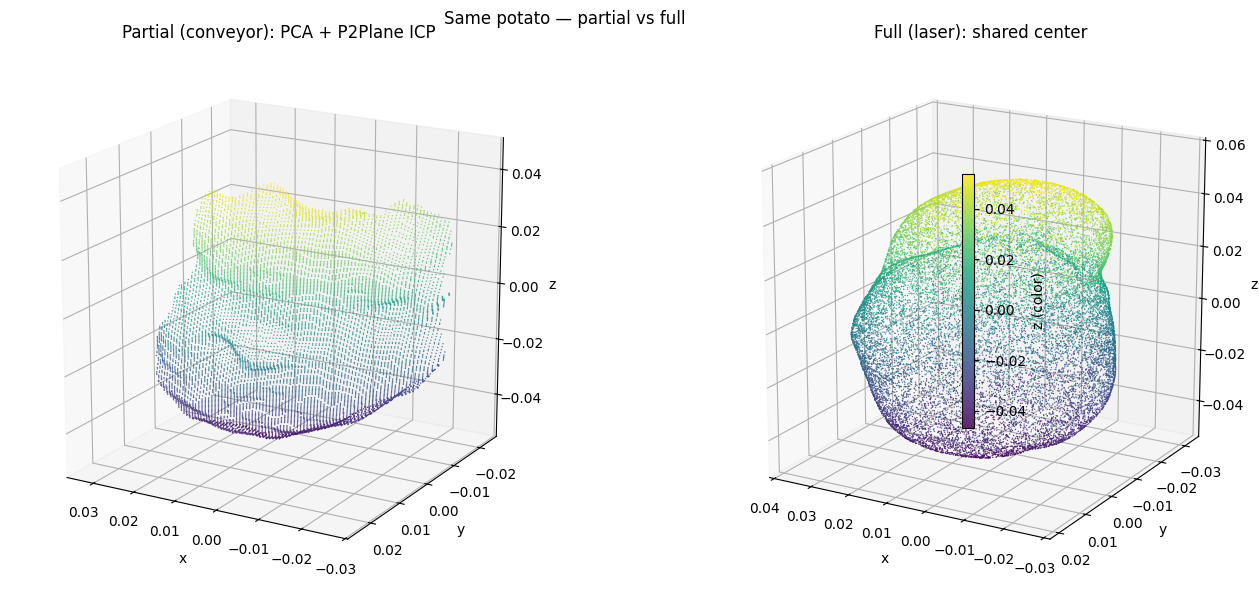

In [42]:
# Partial vs full point cloud — put matching `.ply` files next to this notebook and edit paths below.
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d

ROOT = Path(".").resolve()
PLY_PARTIAL = ROOT / "reviewdata/2025-000_pcd_355.ply"
PLY_FULL = ROOT / "reviewdata/2025-000_20000.ply"

pcd_partial_raw = o3d.io.read_point_cloud(str(PLY_PARTIAL))
pcd_full_raw = o3d.io.read_point_cloud(str(PLY_FULL))


def _pca_rotation_matrix(pts_p: np.ndarray, pts_f: np.ndarray) -> np.ndarray:
    _, _, v_partial = np.linalg.svd(pts_p, full_matrices=False)
    _, _, v_full = np.linalg.svd(pts_f, full_matrices=False)
    axes_p = v_partial.T
    axes_f = v_full.T
    r = axes_f @ axes_p.T
    if np.linalg.det(r) < 0:
        axes_f = axes_f.copy()
        axes_f[:, 2] *= -1
        r = axes_f @ axes_p.T
    return r


def _multiscale_point_to_plane_icp(
    pcd_source: o3d.geometry.PointCloud,
    pcd_target: o3d.geometry.PointCloud,
    extent: float,
) -> np.ndarray:
    """Coarse-to-fine point-to-plane ICP (surface alignment)."""
    voxel_base = max(extent * 0.03, 0.002)
    voxels = [voxel_base * 3.5, voxel_base * 1.8, voxel_base]
    max_iters = [60, 45, 35]
    trans = np.eye(4)
    for vox, mx in zip(voxels, max_iters):
        src = pcd_source.voxel_down_sample(vox)
        tgt = pcd_target.voxel_down_sample(vox)
        src.estimate_normals(
            o3d.geometry.KDTreeSearchParamHybrid(radius=vox * 2.5, max_nn=40)
        )
        tgt.estimate_normals(
            o3d.geometry.KDTreeSearchParamHybrid(radius=vox * 2.5, max_nn=40)
        )
        th = vox * 4.0
        reg = o3d.pipelines.registration.registration_icp(
            src,
            tgt,
            th,
            trans,
            o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=mx),
        )
        trans = reg.transformation
    return trans


def _median_distance_to_target(
    pcd_source: o3d.geometry.PointCloud, pcd_target: o3d.geometry.PointCloud
) -> float:
    d = np.asarray(pcd_source.compute_point_cloud_distance(pcd_target))
    return float(np.median(d))


def _align_one_flip(
    pcd_p_in: o3d.geometry.PointCloud,
    pcd_f_in: o3d.geometry.PointCloud,
    partial_flip: np.ndarray,
) -> tuple[o3d.geometry.PointCloud, o3d.geometry.PointCloud, float]:
    pts_p = (np.asarray(pcd_p_in.points) - np.asarray(pcd_p_in.points).mean(axis=0)) * partial_flip
    pts_f = np.asarray(pcd_f_in.points) - np.asarray(pcd_f_in.points).mean(axis=0)
    r = _pca_rotation_matrix(pts_p, pts_f)
    pts_p = pts_p @ r.T

    pcd_p = o3d.geometry.PointCloud()
    pcd_p.points = o3d.utility.Vector3dVector(pts_p)
    if pcd_p_in.has_colors():
        pcd_p.colors = pcd_p_in.colors
    pcd_f = o3d.geometry.PointCloud()
    pcd_f.points = o3d.utility.Vector3dVector(pts_f)
    if pcd_f_in.has_colors():
        pcd_f.colors = pcd_f_in.colors

    extent = max(np.ptp(pts_p, axis=0).max(), np.ptp(pts_f, axis=0).max())
    trans_icp = _multiscale_point_to_plane_icp(pcd_p, pcd_f, extent)
    pcd_p.transform(trans_icp)

    med = _median_distance_to_target(pcd_p, pcd_f)
    return pcd_p, pcd_f, med


def register_partial_to_full(
    pcd_partial: o3d.geometry.PointCloud, pcd_full: o3d.geometry.PointCloud
) -> tuple[np.ndarray, np.ndarray]:
    """Pick axis flip by lowest median partial->full distance; align with PCA + P2Plane ICP only."""
    best_med = None
    best_flip = None
    for sx in (-1.0, 1.0):
        for sy in (-1.0, 1.0):
            for sz in (-1.0, 1.0):
                flip = np.array([sx, sy, sz])
                _, _, med = _align_one_flip(
                    deepcopy(pcd_partial),
                    deepcopy(pcd_full),
                    flip,
                )
                if best_med is None or med < best_med:
                    best_med = med
                    best_flip = flip.copy()

    assert best_flip is not None
    pcd_p, pcd_f, med_final = _align_one_flip(pcd_partial, pcd_full, best_flip)

    pts_p = np.asarray(pcd_p.points)
    pts_f = np.asarray(pcd_f.points)
    center = np.vstack([pts_p, pts_f]).mean(axis=0)
    pts_p -= center
    pts_f -= center

    print(
        f"Partial axis flip (pre-PCA): ({best_flip[0]:.0f}, {best_flip[1]:.0f}, {best_flip[2]:.0f})  |  "
        f"median dist partial->full: {med_final*1000:.2f} mm"
    )
    return pts_p, pts_f


pts_partial_c, pts_full_c = register_partial_to_full(pcd_partial_raw, pcd_full_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"})
titles = (
    "Partial (conveyor): PCA + P2Plane ICP",
    "Full (laser): shared center",
)
sc = None
elev, azim = 18, 120
for ax, pts, title in zip(axes, (pts_partial_c, pts_full_c), titles):
    sc = ax.scatter(
        pts[:, 0],
        pts[:, 1],
        pts[:, 2],
        c=pts[:, 2],
        cmap="viridis",
        s=1.0,
        alpha=0.85,
        linewidths=0,
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)
fig.colorbar(sc, ax=axes, shrink=0.55, label="z (color)")
fig.suptitle("Same potato — partial vs full")
plt.tight_layout()
plt.show()


In [43]:
# Interactive 3D (rotate / zoom / pan) — requires: pip install open3d plotly
# Run the cell above first: it defines pts_partial_c / pts_full_c (P2Plane + color ICP + shared center).
import numpy as np
import open3d as o3d

if "pts_partial_c" not in globals() or "pts_full_c" not in globals():
    raise RuntimeError("Run the previous cell first so the two clouds are registered and centered together.")

def numpy_to_pcd(pts: np.ndarray, color_rgb: tuple[float, float, float]) -> o3d.geometry.PointCloud:
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    n = pts.shape[0]
    cols = np.tile(np.array(color_rgb, dtype=np.float64), (n, 1))
    pcd.colors = o3d.utility.Vector3dVector(cols)
    return pcd


pcd_p = numpy_to_pcd(pts_partial_c, (1.0, 0.45, 0.1))
pcd_f = numpy_to_pcd(pts_full_c, (0.2, 0.5, 0.95))

# Both clouds in one Plotly scene — use the toolbar to orbit / zoom / reset camera
o3d.visualization.draw_plotly(
    [pcd_p, pcd_f],
    window_name="R9-9 partial (orange) vs full (blue)",
    width=950,
    height=700,
    point_sample_factor=1.0,
)

# Optional: native Open3D window (separate desktop window, full rendering controls)
# o3d.visualization.draw_geometries([pcd_p, pcd_f], window_name="R9-9", width=1280, height=720)


Frames per group:
group
Corolle (2023)      291
Kitahime (2023)     265
Sayaka (2023)       869
Kitahime (2025)    2970


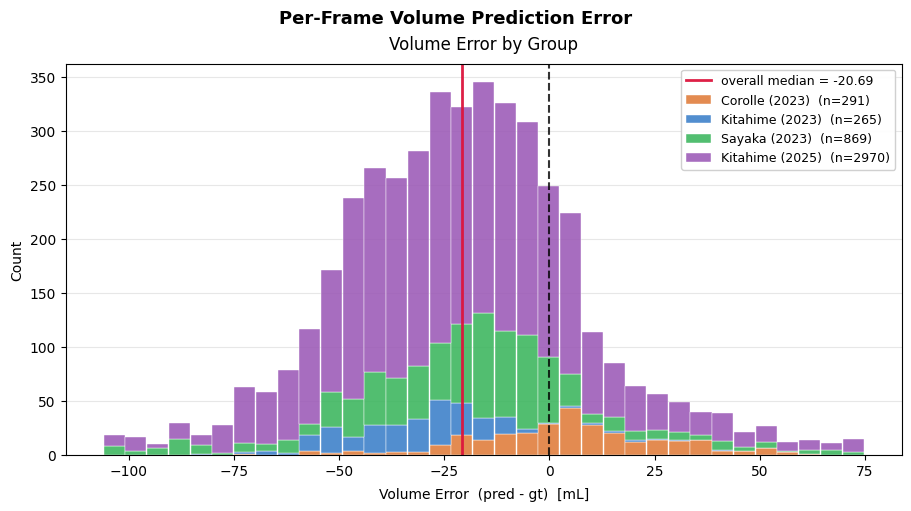

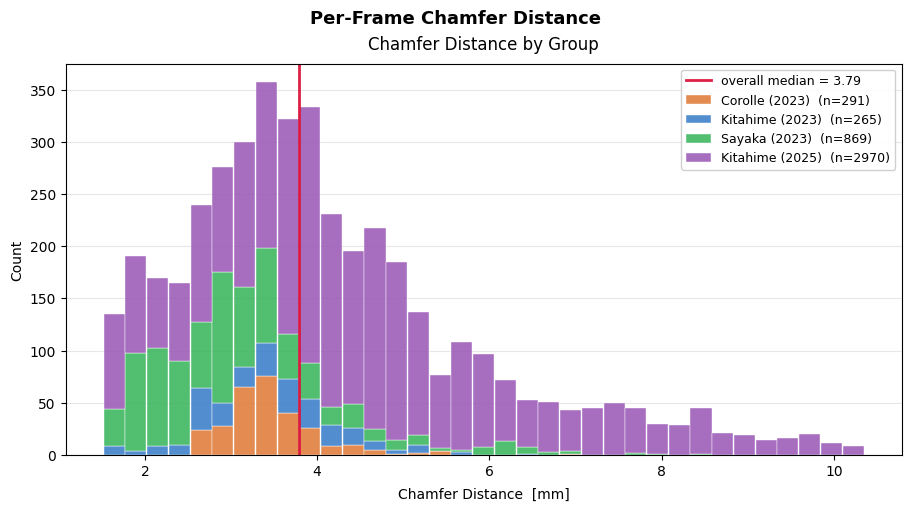


                vol_error                 chamfer_mm              
                     mean  median     std       mean median    std
group                                                             
Corolle (2023)      4.244   4.286  23.538      3.456  3.394  0.563
Kitahime (2023)   -30.756 -29.661  18.063      3.422  3.451  0.864
Sayaka (2023)     -22.629 -18.106  32.746      3.023  2.885  1.116
Kitahime (2025)   -21.391 -22.694  32.570      4.663  4.279  1.991


In [44]:
# Error histograms -- volume error (pred - gt) and Chamfer distance
# Four fixed groups: Corolle 2023 / Kitahime 2023 / Sayaka 2023 / Kitahime 2025
# One frame = one data point (no per-potato aggregation).
#
# Assumes df_frames is already loaded (run cell 2 first).

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build a combined group label from cultivar + year
df = df_frames.copy()
df["vol_error"] = df["pred_volume_ml"] - df["gt_volume_ml"]
df["group"] = (df["cultivar"].astype(str).str.strip()
               + " (" + df["year"].astype(str).str.strip() + ")")

GROUPS  = ["Corolle (2023)", "Kitahime (2023)", "Sayaka (2023)", "Kitahime (2025)"]
PALETTE = ["#E07B39", "#3A7EC9", "#3AB55C", "#9B59B6"]
ALPHA   = 0.88
N_BINS  = 35

df = df[df["group"].isin(GROUPS)]
print("Frames per group:")
print(df["group"].value_counts().reindex(GROUPS).to_string())


def _stacked_hist(ax, metric_col, xlabel, zero_line):
    all_vals = df[metric_col].dropna().values
    lo = np.nanpercentile(all_vals, 1)
    hi = np.nanpercentile(all_vals, 99)
    bins = np.linspace(lo, hi, N_BINS + 1)

    vals_list = [
        df.loc[df["group"] == g, metric_col].dropna().values
        for g in GROUPS
    ]
    counts = np.array([np.histogram(v, bins=bins)[0] for v in vals_list], dtype=float)

    bottoms = np.zeros(len(bins) - 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bar_width = bins[1] - bins[0]

    for i, (group, color) in enumerate(zip(GROUPS, PALETTE)):
        ax.bar(
            bin_centers, counts[i], width=bar_width * 0.97,
            bottom=bottoms, color=color, alpha=ALPHA,
            label=f"{group}  (n={len(vals_list[i])})",
            edgecolor="white", linewidth=0.35,
        )
        bottoms += counts[i]

    if zero_line:
        ax.axvline(0, color="black", linestyle="--", lw=1.5, alpha=0.8)

    med = np.nanmedian(all_vals)
    ax.axvline(med, color="crimson", linestyle="-", lw=2.0, alpha=0.95,
               label=f"overall median = {med:.2f}")

    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel("Count")
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, framealpha=0.92)


# Volume error histogram
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
_stacked_hist(ax, "vol_error", "Volume Error  (pred - gt)  [mL]", zero_line=True)
ax.set_title("Volume Error by Group", pad=10)
fig.suptitle("Per-Frame Volume Prediction Error", fontsize=13, fontweight="bold")
plt.show()

# Chamfer distance histogram
if "chamfer_mm" in df.columns:
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    _stacked_hist(ax, "chamfer_mm", "Chamfer Distance  [mm]", zero_line=False)
    ax.set_title("Chamfer Distance by Group", pad=10)
    fig.suptitle("Per-Frame Chamfer Distance", fontsize=13, fontweight="bold")
    plt.show()

# Summary table
stat_cols = [c for c in ("vol_error", "chamfer_mm") if c in df.columns]
print()
print(df.groupby("group")[stat_cols].agg(["mean", "median", "std"])
      .reindex(GROUPS).round(3).to_string())


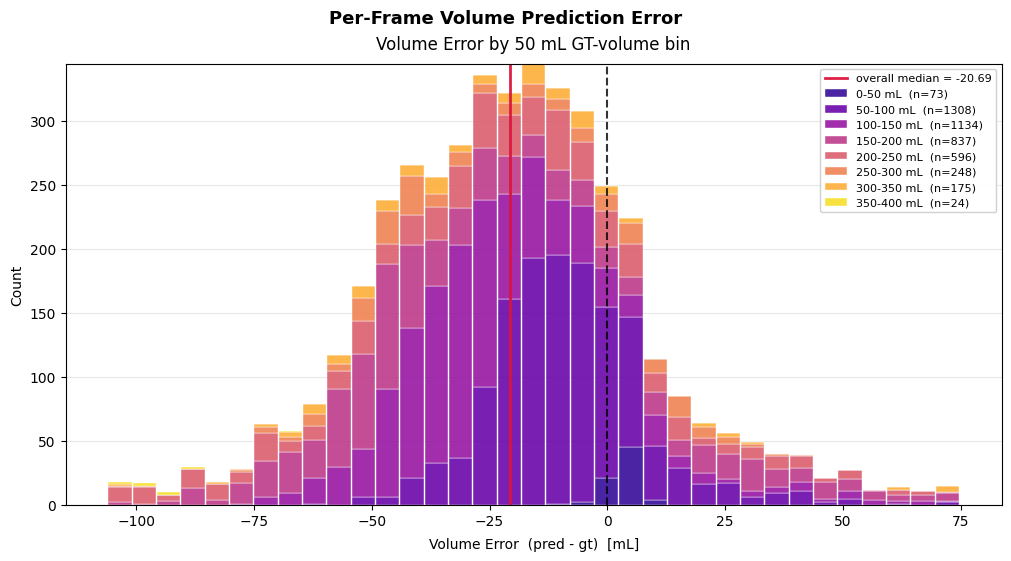

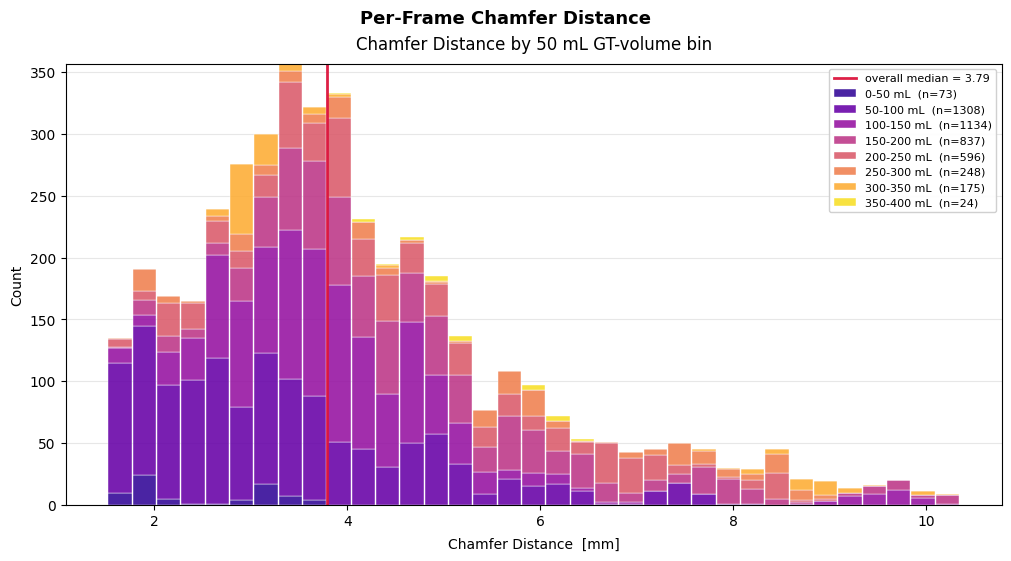


               vol_error                        chamfer_mm                    
                    mean   median     std count       mean median    std count
vol_bin                                                                       
[0.0, 50.0)        2.798    2.959   3.234    73      2.490  2.071  0.690    73
[50.0, 100.0)     -9.168  -10.533  16.293  1308      3.315  3.061  1.410  1308
[100.0, 150.0)   -26.343  -29.710  22.034  1134      3.914  3.715  1.410  1134
[150.0, 200.0)   -26.018  -39.935  39.778   837      4.964  4.518  1.833   837
[200.0, 250.0)   -28.469  -24.372  39.889   596      4.732  4.345  1.725   596
[250.0, 300.0)   -25.560  -31.334  32.774   248      5.307  5.544  2.128   248
[300.0, 350.0)    -3.934  -16.810  55.510   175      5.792  3.287  3.346   175
[350.0, 400.0)  -111.567 -109.513  18.189    24      5.257  5.072  0.743    24


In [45]:
# Same histograms as above, but stacked layers by 50 mL ground-truth volume bins
# One frame = one data point. Assumes df_frames is loaded (run cell 2 first).

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

df = df_frames.copy()
df["vol_error"] = df["pred_volume_ml"] - df["gt_volume_ml"]
df["group"] = (
    df["cultivar"].astype(str).str.strip()
    + " ("
    + df["year"].astype(str).str.strip()
    + ")"
)
GROUPS = ["Corolle (2023)", "Kitahime (2023)", "Sayaka (2023)", "Kitahime (2025)"]
df = df[df["group"].isin(GROUPS)]

ALPHA = 0.88
N_BINS = 35
VOL_BIN_WIDTH = 50
CMAP = plt.cm.plasma


def _vol_bin_edges(volumes: pd.Series) -> np.ndarray:
    lo = float(volumes.min())
    hi = float(volumes.max())
    start = np.floor(lo / VOL_BIN_WIDTH) * VOL_BIN_WIDTH
    end = np.ceil(hi / VOL_BIN_WIDTH) * VOL_BIN_WIDTH
    return np.arange(start, end + VOL_BIN_WIDTH, VOL_BIN_WIDTH)


def _stacked_hist_by_vol_bin(ax, metric_col, xlabel, zero_line):
    sub = df.dropna(subset=[metric_col, "gt_volume_ml"]).copy()
    all_vals = sub[metric_col].values
    lo = np.nanpercentile(all_vals, 1)
    hi = np.nanpercentile(all_vals, 99)
    bins = np.linspace(lo, hi, N_BINS + 1)

    vol_edges = _vol_bin_edges(sub["gt_volume_ml"])
    sub["vol_bin"] = pd.cut(
        sub["gt_volume_ml"],
        bins=vol_edges,
        right=False,
        include_lowest=True,
    )
    vol_categories = [b for b in sub["vol_bin"].cat.categories if (sub["vol_bin"] == b).any()]

    norm = mcolors.Normalize(vmin=vol_edges[0], vmax=vol_edges[-1])

    bottoms = np.zeros(len(bins) - 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bar_width = bins[1] - bins[0]

    for vol_bin in vol_categories:
        vals = sub.loc[sub["vol_bin"] == vol_bin, metric_col].values
        counts, _ = np.histogram(vals, bins=bins)
        mid_vol = (vol_bin.left + vol_bin.right) / 2
        label = f"{int(vol_bin.left)}-{int(vol_bin.right)} mL  (n={len(vals)})"
        ax.bar(
            bin_centers,
            counts,
            width=bar_width * 0.97,
            bottom=bottoms,
            color=CMAP(norm(mid_vol)),
            alpha=ALPHA,
            label=label,
            edgecolor="white",
            linewidth=0.35,
        )
        bottoms += counts

    if zero_line:
        ax.axvline(0, color="black", linestyle="--", lw=1.5, alpha=0.8)

    med = np.nanmedian(all_vals)
    ax.axvline(
        med,
        color="crimson",
        linestyle="-",
        lw=2.0,
        alpha=0.95,
        label=f"overall median = {med:.2f}",
    )

    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel("Count")
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, framealpha=0.92, loc="upper right")


# Volume error histogram
fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
_stacked_hist_by_vol_bin(ax, "vol_error", "Volume Error  (pred - gt)  [mL]", zero_line=True)
ax.set_title("Volume Error by 50 mL GT-volume bin", pad=10)
fig.suptitle("Per-Frame Volume Prediction Error", fontsize=13, fontweight="bold")
plt.show()

# Chamfer distance histogram
if "chamfer_mm" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
    _stacked_hist_by_vol_bin(ax, "chamfer_mm", "Chamfer Distance  [mm]", zero_line=False)
    ax.set_title("Chamfer Distance by 50 mL GT-volume bin", pad=10)
    fig.suptitle("Per-Frame Chamfer Distance", fontsize=13, fontweight="bold")
    plt.show()

# Summary by 50 mL GT-volume bin
df["vol_bin"] = pd.cut(
    df["gt_volume_ml"],
    bins=_vol_bin_edges(df["gt_volume_ml"].dropna()),
    right=False,
    include_lowest=True,
)
stat_cols = [c for c in ("vol_error", "chamfer_mm") if c in df.columns]
print()
print(
    df.groupby("vol_bin", observed=True)[stat_cols]
    .agg(["mean", "median", "std", "count"])
    .round(3)
    .to_string()
)


In [37]:
# Overlap metrics -- precision, recall, F1 (mean per potato / unique_id)
# Same cultivar + year groups as the error histograms above.
# Assumes df_frames is loaded (run cell 1 first).

import pandas as pd

METRIC_COLS = ["precision", "recall", "f1"]
GROUPS = ["Corolle (2023)", "Kitahime (2023)", "Sayaka (2023)", "Kitahime (2025)"]

df = df_frames.copy()
df["group"] = (
    df["cultivar"].astype(str).str.strip()
    + " ("
    + df["year"].astype(str).str.strip()
    + ")"
)
df = df[df["group"].isin(GROUPS)]

missing = [c for c in METRIC_COLS if c not in df.columns]
if missing:
    raise KeyError(f"df_frames missing columns: {missing}")

df_pot = (
    df.groupby(["unique_id", "group"], as_index=False)[METRIC_COLS]
    .mean(numeric_only=True)
)

print("Tubers per group:")
print(df_pot["group"].value_counts().reindex(GROUPS).to_string())
print()
print(
    df_pot.groupby("group")[METRIC_COLS]
    .agg(["mean", "median", "std"])
    .reindex(GROUPS)
    .round(2)
    .to_string()
)

Tubers per group:
group
Corolle (2023)     10
Kitahime (2023)    10
Sayaka (2023)      31
Kitahime (2025)    84

                precision               recall                   f1              
                     mean median    std   mean median    std   mean median    std
group                                                                            
Corolle (2023)      81.34  81.34   6.07  78.61  78.65   5.01  79.82  79.83   5.14
Kitahime (2023)     84.96  89.21   8.34  83.07  88.84   9.76  83.97  89.08   9.05
Sayaka (2023)       85.24  85.85  13.00  83.95  85.08  14.36  84.55  85.44  13.69
Kitahime (2025)     67.90  70.50  19.39  62.94  63.86  19.84  65.15  67.27  19.54


KeyError: 'Column not found: vol_error'

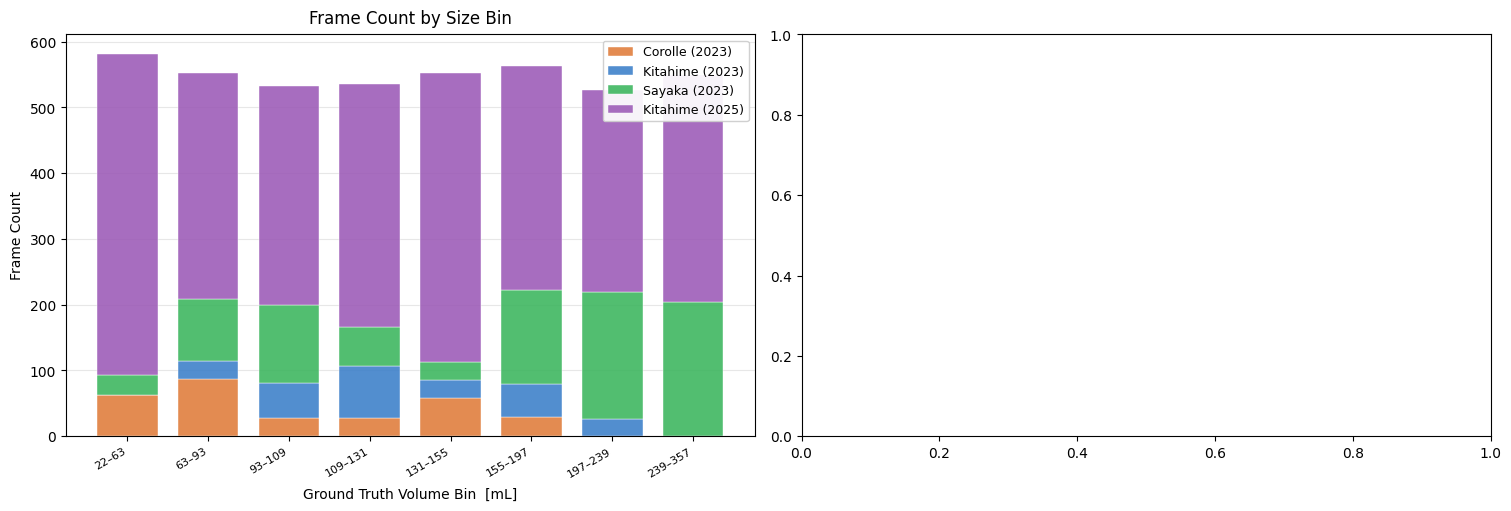

In [13]:
# Same four groups, but x-axis = ground-truth size bins instead of error values.
# Stacked bars show how many frames fall in each size bucket (size distribution).
# Grouped line+marker overlay shows mean error / mean chamfer per size bin.
#
# Assumes df and GROUPS / PALETTE are defined (run the cell above first).

import matplotlib.pyplot as plt
import numpy as np

N_SIZE_BINS = 8

# Build size bins from the gt_volume_ml distribution
bin_edges = np.percentile(df['gt_volume_ml'].dropna(), np.linspace(0, 100, N_SIZE_BINS + 1))
bin_edges = np.unique(bin_edges)  # drop duplicates at the tails
bin_labels = [
    f"{bin_edges[i]:.0f}–{bin_edges[i+1]:.0f}"
    for i in range(len(bin_edges) - 1)
]

df['size_bin'] = pd.cut(
    df['gt_volume_ml'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
)

x = np.arange(len(bin_labels))
bar_w = 0.75


def _size_stacked_count(ax):
    """Stacked bar: count of frames per size bin, coloured by group."""
    bottoms = np.zeros(len(bin_labels))
    for group, color in zip(GROUPS, PALETTE):
        counts = (
            df[df['group'] == group]
            .groupby('size_bin', observed=True)
            .size()
            .reindex(bin_labels, fill_value=0)
            .values
            .astype(float)
        )
        ax.bar(x, counts, width=bar_w, bottom=bottoms,
               color=color, alpha=0.88,
               label=group, edgecolor='white', linewidth=0.35)
        bottoms += counts
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=30, ha='right', fontsize=8)
    ax.set_xlabel('Ground Truth Volume Bin  [mL]', labelpad=6)
    ax.set_ylabel('Frame Count')
    ax.set_title('Frame Count by Size Bin', pad=8)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, framealpha=0.92)


def _size_mean_metric(ax, metric_col, ylabel, zero_line):
    """Grouped bars: mean metric per size bin, one bar group per cultivar/year group."""
    n_groups = len(GROUPS)
    group_w = bar_w / n_groups
    offsets = np.linspace(-(bar_w - group_w) / 2,
                          (bar_w - group_w) / 2, n_groups)
    for group, color, offset in zip(GROUPS, PALETTE, offsets):
        means = (
            df[df['group'] == group]
            .groupby('size_bin', observed=True)[metric_col]
            .mean()
            .reindex(bin_labels)
            .values
        )
        ax.bar(x + offset, means, width=group_w * 0.92,
               color=color, alpha=0.88,
               label=group, edgecolor='white', linewidth=0.35)
    if zero_line:
        ax.axhline(0, color='black', linestyle='--', lw=1.3, alpha=0.75)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=30, ha='right', fontsize=8)
    ax.set_xlabel('Ground Truth Volume Bin  [mL]', labelpad=6)
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, framealpha=0.92)


# Figure 1: count distribution + mean volume error
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
_size_stacked_count(axes[0])
_size_mean_metric(axes[1], 'vol_error',
                  'Mean Volume Error  (pred - gt)  [mL]', zero_line=True)
axes[1].set_title('Mean Volume Error by Size Bin', pad=8)
fig.suptitle('Per-Frame Error vs. Ground-Truth Potato Size',
             fontsize=13, fontweight='bold')
plt.show()

# Figure 2: mean chamfer distance by size bin
if 'chamfer_mm' in df.columns:
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    _size_mean_metric(ax, 'chamfer_mm',
                      'Mean Chamfer Distance  [mm]', zero_line=False)
    ax.set_title('Mean Chamfer Distance by Size Bin', pad=8)
    fig.suptitle('Per-Frame Chamfer Distance vs. Ground-Truth Potato Size',
                 fontsize=13, fontweight='bold')
    plt.show()


## Encoder Input Visualisation

Two **Plotly** 3D panels (orbit / zoom / pan): **partial** scan vs **full** scan for the same tuber, each **centred** by subtracting its own mean. No FPS — only an optional random subsample for display (`DISPLAY_CAP_*`).

Adjust `PLY_PARTIAL` / `PLY_FULL` in the code cell. Run where the `.ply` paths exist (e.g. GPU server).

In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import open3d as o3d
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ROOT = Path('.').resolve()
PLY_PARTIAL = ROOT / 'reviewdata/2025-000_pcd_355.ply'
PLY_FULL = ROOT / 'C:/Users/Jesper/Tilburg University/Thesis/PointSDF_2/data/3DPotatoTwin/2_sfm/2_pcd/2R1-3/2R1-3_20000.ply'

# Same tuber: partial conveyor scan + full laser/SfM cloud.
# Each cloud is translated to its own centroid (no FPS; display subsample only).
# ---------------------------------------------------------------------------
DISPLAY_CAP_FULL = 20000
DISPLAY_CAP_PARTIAL_RAW = 20000
PARTIAL_CLR = '#4C72B0'
FULL_CLR = '#6AAF7C'

MARKER_PARTIAL = dict(size=1, opacity=0.4, line=dict(width=0))
MARKER_FULL = dict(size=1, opacity=0.4, line=dict(width=0))

DEFAULT_CAMERA = dict(eye=dict(x=1.45, y=1.45, z=1.28))


def _downsample(pts: np.ndarray, max_n: int, seed: int) -> np.ndarray:
    n = len(pts)
    if n <= max_n:
        return pts
    g = np.random.default_rng(seed)
    idx = g.choice(n, max_n, replace=False)
    return pts[idx]


def _load_centred(ply_path: Path) -> tuple[np.ndarray, np.ndarray]:
    pcd = o3d.io.read_point_cloud(str(ply_path))
    raw = np.asarray(pcd.points, dtype=np.float32)
    centred = raw - raw.mean(axis=0)
    return raw, centred


raw_p, centred_p = _load_centred(PLY_PARTIAL)
raw_f, centred_f = _load_centred(PLY_FULL)

centred_p_viz = _downsample(centred_p, DISPLAY_CAP_PARTIAL_RAW, seed=11)
centred_f_viz = _downsample(centred_f, DISPLAY_CAP_FULL, seed=12)


def _scene_ranges(pts: np.ndarray) -> tuple[list[float], list[float], list[float]]:
    if len(pts) == 0:
        return [-0.15, 0.15], [-0.15, 0.15], [-0.15, 0.15]
    lo, hi = pts.min(0), pts.max(0)
    center = (lo + hi) / 2
    r = max(float((hi - lo).max()) / 2, 0.02) + 0.01
    return (
        [center[0] - r, center[0] + r],
        [center[1] - r, center[1] + r],
        [center[2] - r, center[2] + r],
    )


def _trace(
    pts: np.ndarray,
    color: str,
    name: str,
    *,
    marker: dict,
    showlegend: bool = False,
    hover_skip: bool = False,
) -> go.Scatter3d:
    m = {**marker, 'color': color, 'line': dict(width=0)}
    ht = '<extra></extra>' if hover_skip else (
        name + '<br>x=%{x:.4f} m<br>y=%{y:.4f} m<br>z=%{z:.4f} m<extra></extra>'
    )
    return go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode='markers',
        marker=m,
        name=name,
        showlegend=showlegend,
        hovertemplate=ht,
    )


fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=(
        f'Partial — centred (showing ≤{min(len(centred_p), DISPLAY_CAP_PARTIAL_RAW):,} of {len(raw_p):,} pts)',
        f'Full — centred (showing ≤{min(len(centred_f), DISPLAY_CAP_FULL):,} of {len(raw_f):,} pts)',
    ),
    horizontal_spacing=0.06,
)

fig.add_trace(
    _trace(
        centred_p_viz,
        PARTIAL_CLR,
        'Partial',
        marker=MARKER_PARTIAL,
        showlegend=False,
        hover_skip=len(centred_p_viz) > 6000,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    _trace(
        centred_f_viz,
        FULL_CLR,
        'Full',
        marker=MARKER_FULL,
        showlegend=False,
        hover_skip=len(centred_f_viz) > 8000,
    ),
    row=1,
    col=2,
)

axis_style = dict(
    showbackground=True,
    backgroundcolor='rgb(248,248,250)',
    gridcolor='white',
    title_font_size=10,
    showspikes=False,
)

xr1, yr1, zr1 = _scene_ranges(centred_p_viz)
xr2, yr2, zr2 = _scene_ranges(centred_f_viz)

for scene_idx, (xr, yr, zr) in enumerate([(xr1, yr1, zr1), (xr2, yr2, zr2)]):
    scene_kw = dict(
        xaxis={**axis_style, 'title': 'X (m)', 'range': xr},
        yaxis={**axis_style, 'title': 'Y (m)', 'range': yr},
        zaxis={**axis_style, 'title': 'Z (m)', 'range': zr},
        aspectmode='cube',
        camera=DEFAULT_CAMERA,
        dragmode='orbit',
    )
    key = 'scene' if scene_idx == 0 else f'scene{scene_idx + 1}'
    fig.update_layout(**{key: scene_kw})

fig.update_layout(
    title_text=f'Centred point clouds | {PLY_PARTIAL.name} · {PLY_FULL.name}',
    title_font_size=14,
    height=520,
    margin=dict(l=0, r=0, t=72, b=0),
    paper_bgcolor='white',
)

fig.show()

print(f'\nPartial n={len(raw_p):>6,} (centred)  bbox {(raw_p.max(0)-raw_p.min(0))}')
print(f'Full    n={len(raw_f):>6,} (centred)  bbox {(raw_f.max(0)-raw_f.min(0))}')
print(
    f'Display subsample caps: partial<={DISPLAY_CAP_PARTIAL_RAW}, full<={DISPLAY_CAP_FULL}'
)



Partial n=10,530 (centred)  bbox [0.09415747 0.05897591 0.044     ]
Full    n=20,000 (centred)  bbox [0.0560676  0.05791207 0.06363179]
Display subsample caps: partial<=20000, full<=20000
